# Implementation of Dice Loss in PyTorch

In [2]:
import torch
import torch.nn as nn


class DiceBoxLoss(nn.Module):
    """
    Computes the Soft Dice Loss for YOLO bounding boxes:
    
        L = 1 - (2I + eps) / (A_gt + A_pred + eps)
        
    where boxes are in format (x_center, y_center, w, h).
    """

    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, pred_boxes, gt_boxes):
        """
        pred_boxes: (batch, S, S, B, 4)
        gt_boxes:   (batch, S, S, B, 4)
        """

        # Unpack
        x_p, y_p, w_p, h_p = pred_boxes[..., 0], pred_boxes[..., 1], pred_boxes[..., 2], pred_boxes[..., 3]
        x_g, y_g, w_g, h_g =  gt_boxes[..., 0],  gt_boxes[..., 1],  gt_boxes[..., 2],  gt_boxes[..., 3]

        # Convert center format → corner format
        x1_p = x_p - w_p / 2
        y1_p = y_p - h_p / 2
        x2_p = x_p + w_p / 2
        y2_p = y_p + h_p / 2

        x1_g = x_g - w_g / 2
        y1_g = y_g - h_g / 2
        x2_g = x_g + w_g / 2
        y2_g = y_g + h_g / 2

        # Intersection area
        x1_int = torch.max(x1_p, x1_g)
        y1_int = torch.max(y1_p, y1_g)
        x2_int = torch.min(x2_p, x2_g)
        y2_int = torch.min(y2_p, y2_g)

        w_int = torch.clamp(x2_int - x1_int, min=0)
        h_int = torch.clamp(y2_int - y1_int, min=0)
        I = w_int * h_int

        # Areas
        A_p = w_p * h_p
        A_g = w_g * h_g

        # Dice box loss
        dice = (2 * I + self.eps) / (A_g + A_p + self.eps)
        loss = 1 - dice

        return loss   # shape: (batch, S, S, B)


In [23]:
class YOLODiceLoss(nn.Module):
    def __init__(self, S=7, B=2, num_classes=20, lambda_noobj=0.5, eps=1e-6):
        super().__init__()
        self.S = S
        self.B = B
        self.num_classes = num_classes
        self.lambda_noobj = lambda_noobj

        self.dice_loss = DiceBoxLoss(eps=eps)
        self.mse = nn.MSELoss(reduction='none')

    def forward(self, pred, target):
        """
        pred, target shapes:
            (batch, S, S, B*5 + C)

        box format: [x, y, w, h, conf]  (per box)
        class probabilities: C numbers
        """

        batch = pred.size(0)
        S, B, C = self.S, self.B, self.num_classes

        # Split predictions
        pred_boxes = pred[..., :B*5].view(batch, S, S, B, 5)
        pred_cls = pred[..., B*5:]  # (batch, S, S, C)

        # Split targets
        target_boxes = target[..., :B*5].view(batch, S, S, B, 5)
        target_cls = target[..., B*5:]  # (batch, S, S, C)

        # Object mask
        obj_mask = target_boxes[..., 4]  # shape: (batch, S, S, B)
        noobj_mask = 1 - obj_mask

        # 1) Localization loss using DiceBox
        pred_xywh = pred_boxes[..., 0:4]
        gt_xywh   = target_boxes[..., 0:4]

        dice_loss = self.dice_loss(pred_xywh, gt_xywh)
        dice_loss = dice_loss * obj_mask
        dice_loss = dice_loss.sum() / batch

        # 2) Confidence loss
        pred_conf = pred_boxes[..., 4]
        gt_conf = target_boxes[..., 4]

        conf_loss_obj = self.mse(pred_conf, gt_conf) * obj_mask
        conf_loss_noobj = self.mse(pred_conf, gt_conf) * noobj_mask

        conf_loss = conf_loss_obj.sum() + self.lambda_noobj * conf_loss_noobj.sum()
        conf_loss /= batch

        # 3) Classification loss
        # mask per cell (not per box)
        # cell has object if ANY box has object
        cell_obj_mask = (obj_mask.sum(dim=3) > 0).float().unsqueeze(-1)  # (batch,S,S,1)

        cls_loss = self.mse(pred_cls, target_cls) * cell_obj_mask
        cls_loss = cls_loss.sum() / batch

        total_loss = dice_loss + conf_loss + cls_loss

        return total_loss, dice_loss, conf_loss, cls_loss


# Calculating Dice Loss, Classification Loss, Confidence Loss, and Total Loss

In [24]:
import torch

# Test Setting
S = 2
B = 1
C = 1
batch = 1

loss_fn = YOLODiceLoss(S=S, B=B, num_classes=C)

########################################
# with overlap
########################################

target = torch.zeros((batch, S, S, B*5 + C))

# Building Target
target[0,0,0,0] = 0.5  # x
target[0,0,0,1] = 0.5  # y
target[0,0,0,2] = 0.4  # w
target[0,0,0,3] = 0.4  # h
target[0,0,0,4] = 1.0  # confidence
target[0,0,0,5] = 1.0  # class

# prediction = target
pred_perfect = target.clone()

total, dice, conf, cls = loss_fn(pred_perfect, target)

print("CASE A: Perfect Prediction")
print("Total Loss:", total.item())
print("Dice Loss:", dice.item())
print("Conf Loss:", conf.item())
print("Cls Loss:", cls.item())


########################################
# With out overlap
########################################

pred_bad = target.clone()

# Moving box
pred_bad[0,0,0,0] = 0.1  # x
pred_bad[0,0,0,1] = 0.1  # y

total, dice, conf, cls = loss_fn(pred_bad, target)

print("\nCASE B: No Overlap")
print("Total Loss:", total.item())
print("Dice Loss:", dice.item())
print("Conf Loss:", conf.item())
print("Cls Loss:", cls.item())

CASE A: Perfect Prediction
Total Loss: 1.7881393432617188e-07
Dice Loss: 1.7881393432617188e-07
Conf Loss: 0.0
Cls Loss: 0.0

CASE B: No Overlap
Total Loss: 0.9999969005584717
Dice Loss: 0.9999969005584717
Conf Loss: 0.0
Cls Loss: 0.0


# Visualization

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_boxes(gt, pred):

    fig, ax = plt.subplots(figsize=(5,5))

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    # Converting tensor to float
    xg = float(gt[0,0,0,0])
    yg = float(gt[0,0,0,1])
    wg = abs(float(gt[0,0,0,2]))
    hg = abs(float(gt[0,0,0,3]))

    xp = float(pred[0,0,0,0])
    yp = float(pred[0,0,0,1])
    wp = abs(float(pred[0,0,0,2]))
    hp = abs(float(pred[0,0,0,3]))

    # center → corner
    xg1 = xg - wg/2
    yg1 = yg - hg/2
    xp1 = xp - wp/2
    yp1 = yp - hp/2

    # GT box
    gt_box = patches.Rectangle(
        (xg1,yg1),wg,hg,
        linewidth=3,
        edgecolor='green',
        facecolor='green',
        alpha=0.2,
        label="Ground Truth"
    )

    # Pred box
    pred_box = patches.Rectangle(
        (xp1,yp1),wp,hp,
        linewidth=3,
        edgecolor='red',
        linestyle='--',
        facecolor='none',
        label="Prediction"
    )

    ax.add_patch(gt_box)
    ax.add_patch(pred_box)

    # Plotting the center of the box
    ax.scatter(xg, yg, color='green', s=80)
    ax.scatter(xp, yp, color='red', s=80)

    ax.legend()
    ax.set_title("Bounding Box Visualization")
    ax.set_aspect('equal')

    plt.show()


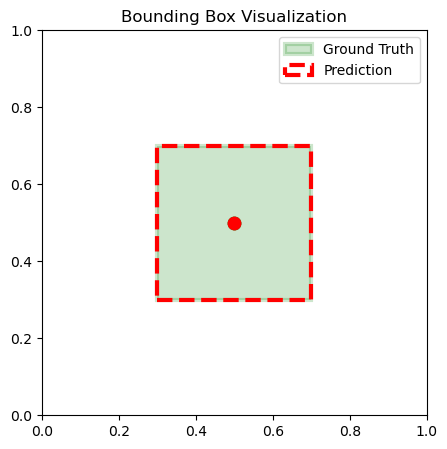

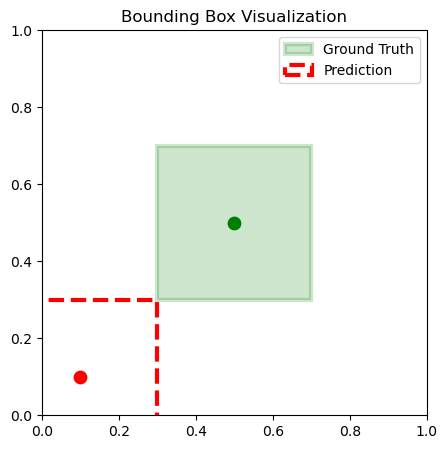

In [20]:
draw_boxes(target, pred_perfect)
draw_boxes(target, pred_bad)